In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10

In [3]:
(X_train, y_train),(X_test, y_test)= cifar10.load_data()

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


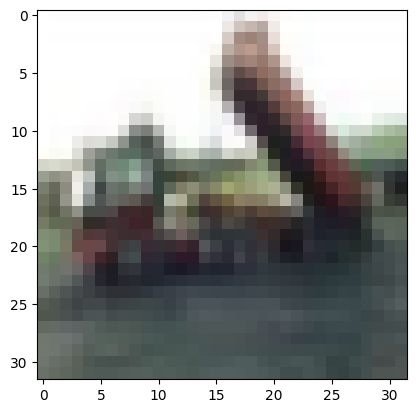

In [5]:
plt.imshow(X_train[2])

In [6]:
X_train = X_train /255
X_test = X_test /255

In [7]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0


In [8]:
print(y_train[:6])

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]]


In [9]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [10]:
print(y_train.shape)
print(y_train[:3])

(50000, 10)
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [11]:
model2 = keras.Sequential([keras.Input(shape=(32,32,3))])

In [12]:
model2.add(keras.layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    activation='relu',
))

model2.add(keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model2.add(keras.layers.BatchNormalization())

model2.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model2.add(keras.layers.Dropout(0.25))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,272 (40.12 KB)

 Trainable params: 10,208 (39.88 KB)

 Non-trainable params: 64 (256.00 B)

In [13]:
model2.add(keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model2.add(keras.layers.BatchNormalization())

model2.add(keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model2.add(keras.layers.BatchNormalization())


model2.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(keras.layers.Dropout(0.25))

model2.add(keras.layers.GlobalAveragePooling2D())
model2.add(keras.layers.Dense(64, activation='relu'))
model2.add(keras.layers.BatchNormalization())

model2.add(keras.layers.Dropout(0.3))
model2.add(keras.layers.Dense(10, activation='softmax'))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,274 (278.41 KB)

 Trainable params: 70,826 (276.66 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
from keras.callbacks import EarlyStopping

model2.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
history2 = model2.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3912 - loss: 1.6813 - val_accuracy: 0.4471 - val_loss: 1.4803
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.5450 - loss: 1.2713 - val_accuracy: 0.5945 - val_loss: 1.1376
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.5923 - loss: 1.1396 - val_accuracy: 0.6045 - val_loss: 1.1109
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.6248 - loss: 1.0545 - val_accuracy: 0.5897 - val_loss: 1.1317
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.6532 - loss: 0.9937 - val_accuracy: 0.6220 - val_loss: 1.1024
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.6672 - loss: 0.9439 - val_accuracy: 0.6519 - val_loss: 0.9829
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.6870 - loss: 0.8958 - val_accuracy: 0.7010 - val_loss: 0.8507
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 36ms/step - accuracy: 0.6964 -

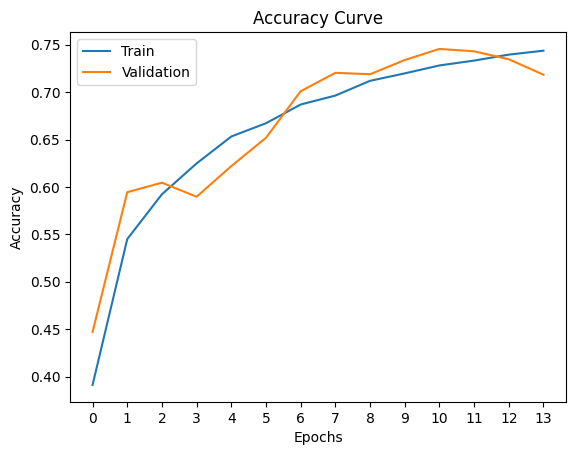

In [16]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(len(history2.history['accuracy'])))
plt.legend(["Train","Validation"])
plt.show()

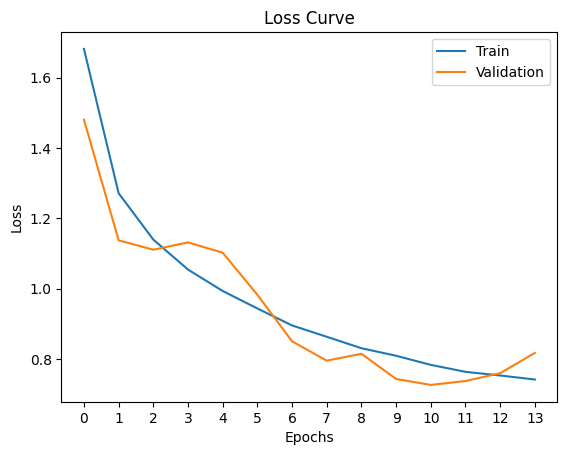

In [17]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(len(history2.history['loss'])))
plt.legend(["Train","Validation"])
plt.show()

In [18]:
test_loss, test_acc =model2.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7396 - loss: 0.7415
Test Accuracy: 0.7396000027656555
Test loss: 0.7414628863334656


In [19]:
y_pred = model2.predict(X_test)
y_pred =np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


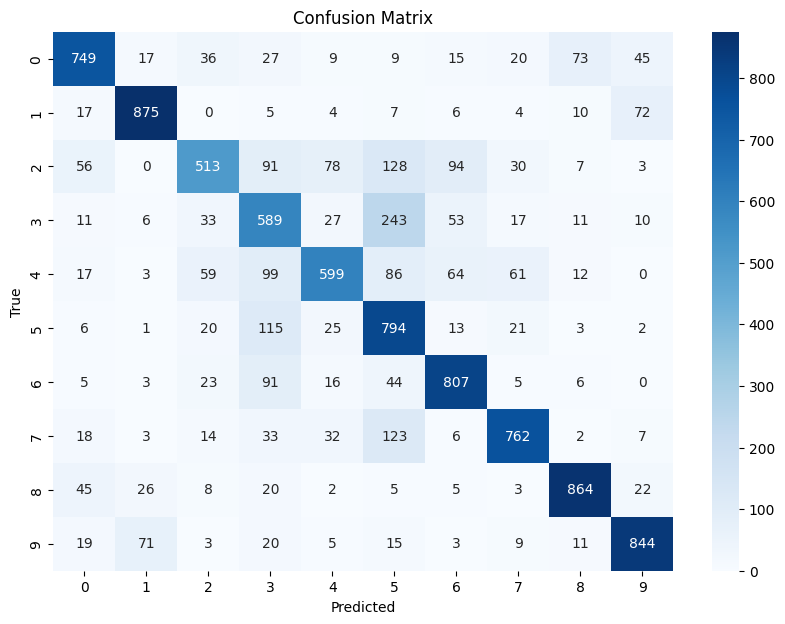

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77      1000
           1       0.87      0.88      0.87      1000
           2       0.72      0.51      0.60      1000
           3       0.54      0.59      0.56      1000
           4       0.75      0.60      0.67      1000
           5       0.55      0.79      0.65      1000
           6       0.76      0.81      0.78      1000
           7       0.82      0.76      0.79      1000
           8       0.86      0.86      0.86      1000
           9       0.84      0.84      0.84      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000

